In [1]:
# Package Imports - copy and paste
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

In [2]:
# Load the data - copy and paste
file_location = 'https://joannabieri.com/introdatascience/data/lego_sample.csv'
DF = pd.read_csv(file_location)

In [4]:
# Look at the data - copy and paste
(DF)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size
0,10859,My First Ladybird,DUPLO®,6,4.99,16.00,2018,Ages_1½-3,9,NaN,Box,NaN,5,Large
1,10860,My First Race Car,DUPLO®,6,4.99,9.45,2018,Ages_1½-3,9,NaN,Box,0.13Kg (0.29 lb),6,Large
2,10862,My First Celebration,DUPLO®,41,14.99,39.89,2018,Ages_1½-3,9,NaN,Box,NaN,18,Large
3,10864,Large Playground Brick Box,DUPLO®,71,49.99,56.69,2018,Ages_2-5,32,2.0,Plastic box,1.41Kg (3.11 lb),49,Large
4,10867,Farmers' Market,DUPLO®,26,19.99,36.99,2018,Ages_2-5,9,3.0,Box,NaN,18,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,60251,Monster Truck,City,55,9.99,8.99,2020,Ages_5+,32,1.0,Box,0.14Kg (0.31 lb),34,Small
71,60252,Construction Bulldozer,City,126,19.99,15.99,2020,Ages_4+,84,2.0,Box,0.35Kg (0.78 lb),81,Small
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small


In [7]:
# a. there are 14 variables and 75 observations
# b. the names of all the variables are item_number, set_name, theme, pieces, price, amazon_price, year, ages, pages, minifigures, packaging, weight, unique_pieces, size
# c. numerical: pieces (discrete), price (continuous), amazon_price (continous), year (discrete), pages (discrete), weight (continuous), unique_pieces (discrete)
# categorical: item_number (nominal), set_name (nominal), theme (nominal), ages (ordinal), minifigures (discrete), packaging (nominal), size (ordinal)
# d.
(DF).describe().round(2)

,item_number,pieces,price,amazon_price,year,pages,minifigures,unique_pieces
count,75.00,75.00,75.00,75.00,75.00,75.00,65.00,75.00
mean,37498.49,196.45,32.14,39.39,2019.05,73.21,2.62,96.67
std,20461.27,213.91,27.75,33.30,0.82,76.95,2.13,89.47
min,10859.00,6.00,4.99,6.29,2018.00,1.00,1.00,5.00
25%,10916.50,37.00,9.99,17.98,2018.00,14.00,1.00,30.00
50%,41378.00,93.00,19.99,29.99,2019.00,44.00,2.00,61.00
75%,60193.00,323.50,39.99,53.94,2020.00,116.00,3.00,151.00
max,60267.00,897.00,149.99,184.99,2020.00,389.00,15.00,411.00


In [8]:
# d.
#1 this data was recorded only from the years 2018-2020
#2 the minofigures column must have ten NaNs because there are only 65 total and the rest have 75
#3 for the pieces, the mean is 196 but the median is 93, suggesting that very few high count pices are skewing the mean upward
#4 there is an outlier in the minifigures, 15, because it is proportionally and significantly higher than the 75%

In [13]:
categories = ['set_name', 'theme', 'ages', 'minifigures', 'packaging', 'size']
DF_categories = DF[categories]
show(DF_categories)

Loading ITables v2.5.2 from the internet... (need help?)


In [21]:
counts = DF_categories['set_name'].value_counts()
show(counts)
# this was a stupid one to do the value counts to because there is only one of each

Loading ITables v2.5.2 from the internet... (need help?)


In [22]:
counts = DF_categories['ages'].value_counts()
show(counts)
# the Ages_6+ categry seems to be the most popular age target for these sets

Loading ITables v2.5.2 from the internet... (need help?)


In [23]:
counts = DF_categories['theme'].value_counts()
show(counts)
# interesting they probably took 25 of each theme on purpose since they all target different audiences

Loading ITables v2.5.2 from the internet... (need help?)


In [24]:
counts = DF_categories['minifigures'].value_counts()
show(counts)
# 1, 2, and 3 is the most popular amount of minifigures

Loading ITables v2.5.2 from the internet... (need help?)


In [25]:
counts = DF_categories['packaging'].value_counts()
show(counts)
# they are almost all in a box

Loading ITables v2.5.2 from the internet... (need help?)


In [26]:
counts = DF_categories['size'].value_counts()
show(counts)
# nice clean numbers and only two different counts

Loading ITables v2.5.2 from the internet... (need help?)


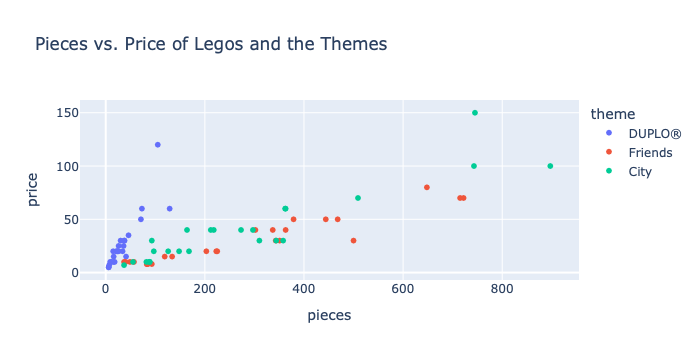

In [34]:
fig = px.scatter(DF,
                 x='pieces',
                 y='price',
                 color='theme',
                 title='Pieces vs. Price of Legos and the Themes',
hover_data='set_name')
fig.show()

In [35]:
# yes more expensive sets tend to have more pieces because if I were to draw a line that best suits the graph it would look like its projecting upward.
# the most expensive set lies at (745, 149.99) and is City theme and set_name is Ocean Exploring Ship.
# DUPLO seems to be the least amount of pieces and the lowest price. Friends looks maybe a little bit cheaper than City, whith City having simultaniously the sets with the most amount of pieces and the highest price.
# (105, 119.99), (745, 149.99), and maybe (897, 99.99) appear to be possible outliers.

In [48]:
DF['Price_Difference'] = DF['amazon_price'] - DF['price']
(DF['Price_Difference'])
# when the prices are positive this means that amazon charges more than retail

0     11.01
1      4.46
2     24.90
3      6.70
4     17.00
      ...  
70    -1.00
71    -4.00
72     0.00
73     0.00
74    -2.00
Name: Price_Difference, Length: 75, dtype: float64

In [55]:
grouped = DF.groupby('theme')['Price_Difference'].describe()
grouped.T
# I looked up how to flip the rows and the columns because I found it difficult to read.
# Amazon chargres more than retail on DUPLO and Friends more than City.
# Friends has the highest Amazon-to-retail margin at $115.
# Friends with greater standard deviation implies greater variability.
# I found it interesting thatall of thr medians are really similar but Friends has the highest max.

theme,City,DUPLO®,Friends
count,25.000000,25.000000,25.000000
mean,5.399600,7.392400,8.979200
std,15.243677,16.996152,24.047927
min,-13.990000,-5.000000,-9.990000
25%,-4.010000,-2.000000,-0.040000
50%,-1.000000,0.000000,3.960000
75%,12.000000,11.010000,8.940000
max,39.960000,69.000000,115.000000


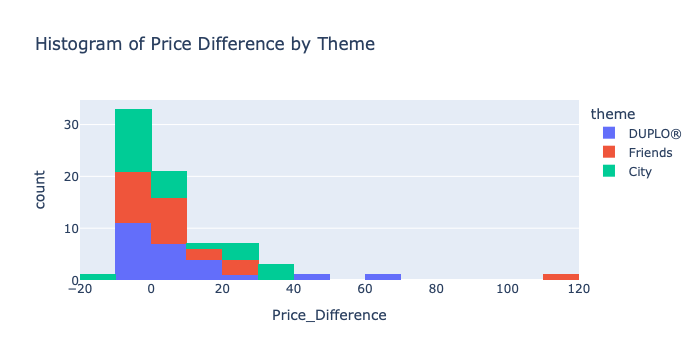

In [63]:
fig = px.histogram(DF,
             x='Price_Difference',
            color='theme',
            title='Histogram of Price Difference by Theme')
fig.update_traces(dict(marker_line_width=0))
fig.show()

In [68]:
mask = DF['price'] == DF['price'].max()
most_expensive_set = DF[mask]
most_expensive_set
# 745 pieces, $149.99 (price = amazon_price in this situation)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.0


In [69]:
mask = DF['amazon_price'] == DF['amazon_price'].max()
most_expensive_set = DF[mask]
most_expensive_set

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,115.0
